# ENTREGABLE 2

# INSTRUCCIONES

Realizar la segunda fase del análisis exploratorio usando el archivo CSV (`dataset_banco_clean.csv`) con 45189 filas y 17 columnas.

# Problema

Una entidad bancaria contrata a una empresa de marketing encargada de contactar telefónicamente a posibles clientes para determinar si están interesados o no en adquirir un certificado de depósito a término con el banco.

¿Qué perfil tienen los clientes con mayor potencial de conversión?

# El set de datos después de la limpieza

Cada registro contiene 16 características (las primeras 16 columnas) y una categoría ("yes" o "no" dependiendo de si la persona está o no interesada en adquirir el producto). Las columnas son:

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente)
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings

# Ignorar los warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [3]:
ruta = "./dataset_banco_clean.csv"
data = pd.read_csv(ruta)

In [4]:
print(data.shape)
data.head()

(45189, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [5]:
ProfileReport(data)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Análisis exploratorio

La idea es usar herramientas estadísticas y de visualización para:

- Crear un mapa mental del set de datos (entenderlo)
- Empezar a encontrar respuestas a la pregunta planteada inicialmente (¿qué perfil tienen los clientes con mayor potencial de conversión?)

Llevaremos a cabo estas fases:

1. Análisis de cada variable de manera individual
2. Análisis univariado: relación de cada variable predictora con la variable a predecir
3. Análisis bivariado: relación de pares de variables predictoras con la variable a predecir

Para cada una de ellas generar un pequeño resumen

## 1. Análisis de cada variable

### Variables Numéricas

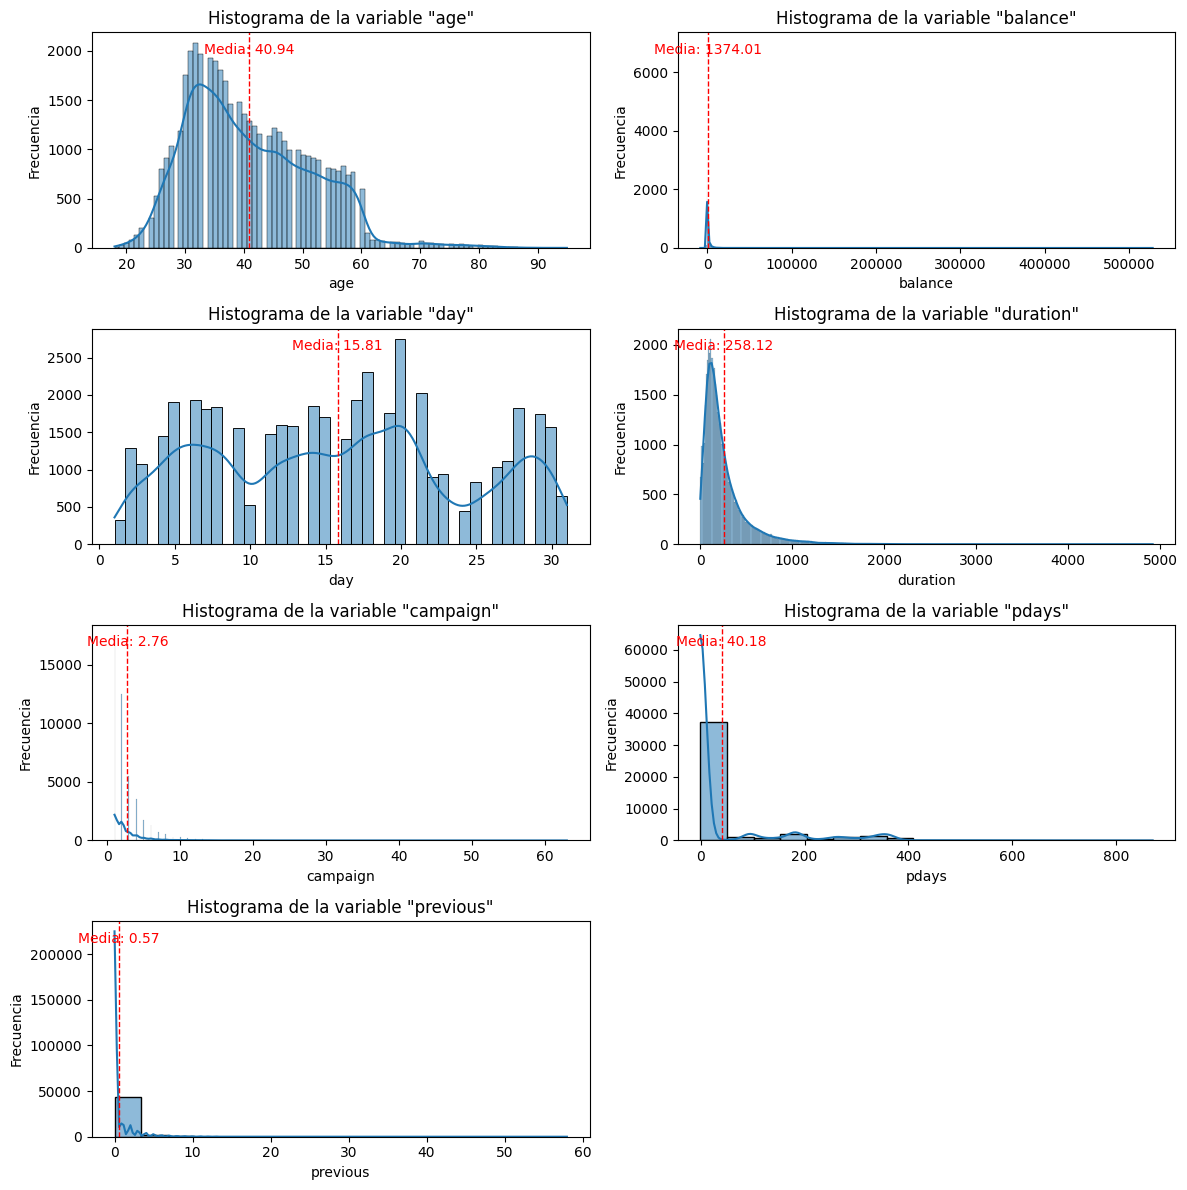

In [6]:
# Histogramas para variables numéricas
numeric_vars = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
num_plots = len(numeric_vars)
num_rows = num_plots // 2 + num_plots % 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))

for i, var in enumerate(numeric_vars):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]
    sns.histplot(data=data, x=var, kde=True, ax=ax, palette="pastel")
    mean_value = data[var].mean()
    ax.axvline(mean_value, color='red', linestyle='dashed', linewidth=1)
    ax.text(mean_value, ax.get_ylim()[1]*0.9, f'Media: {mean_value:.2f}', color='red', fontsize=10, ha='center')
    ax.set_title(f'Histograma de la variable "{var}"')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')

# Eliminar subplots vacíos
for i in range(num_plots, num_rows*num_cols):
    axes.flatten()[i].remove()

plt.tight_layout()
plt.show()


### Variables Categóricas

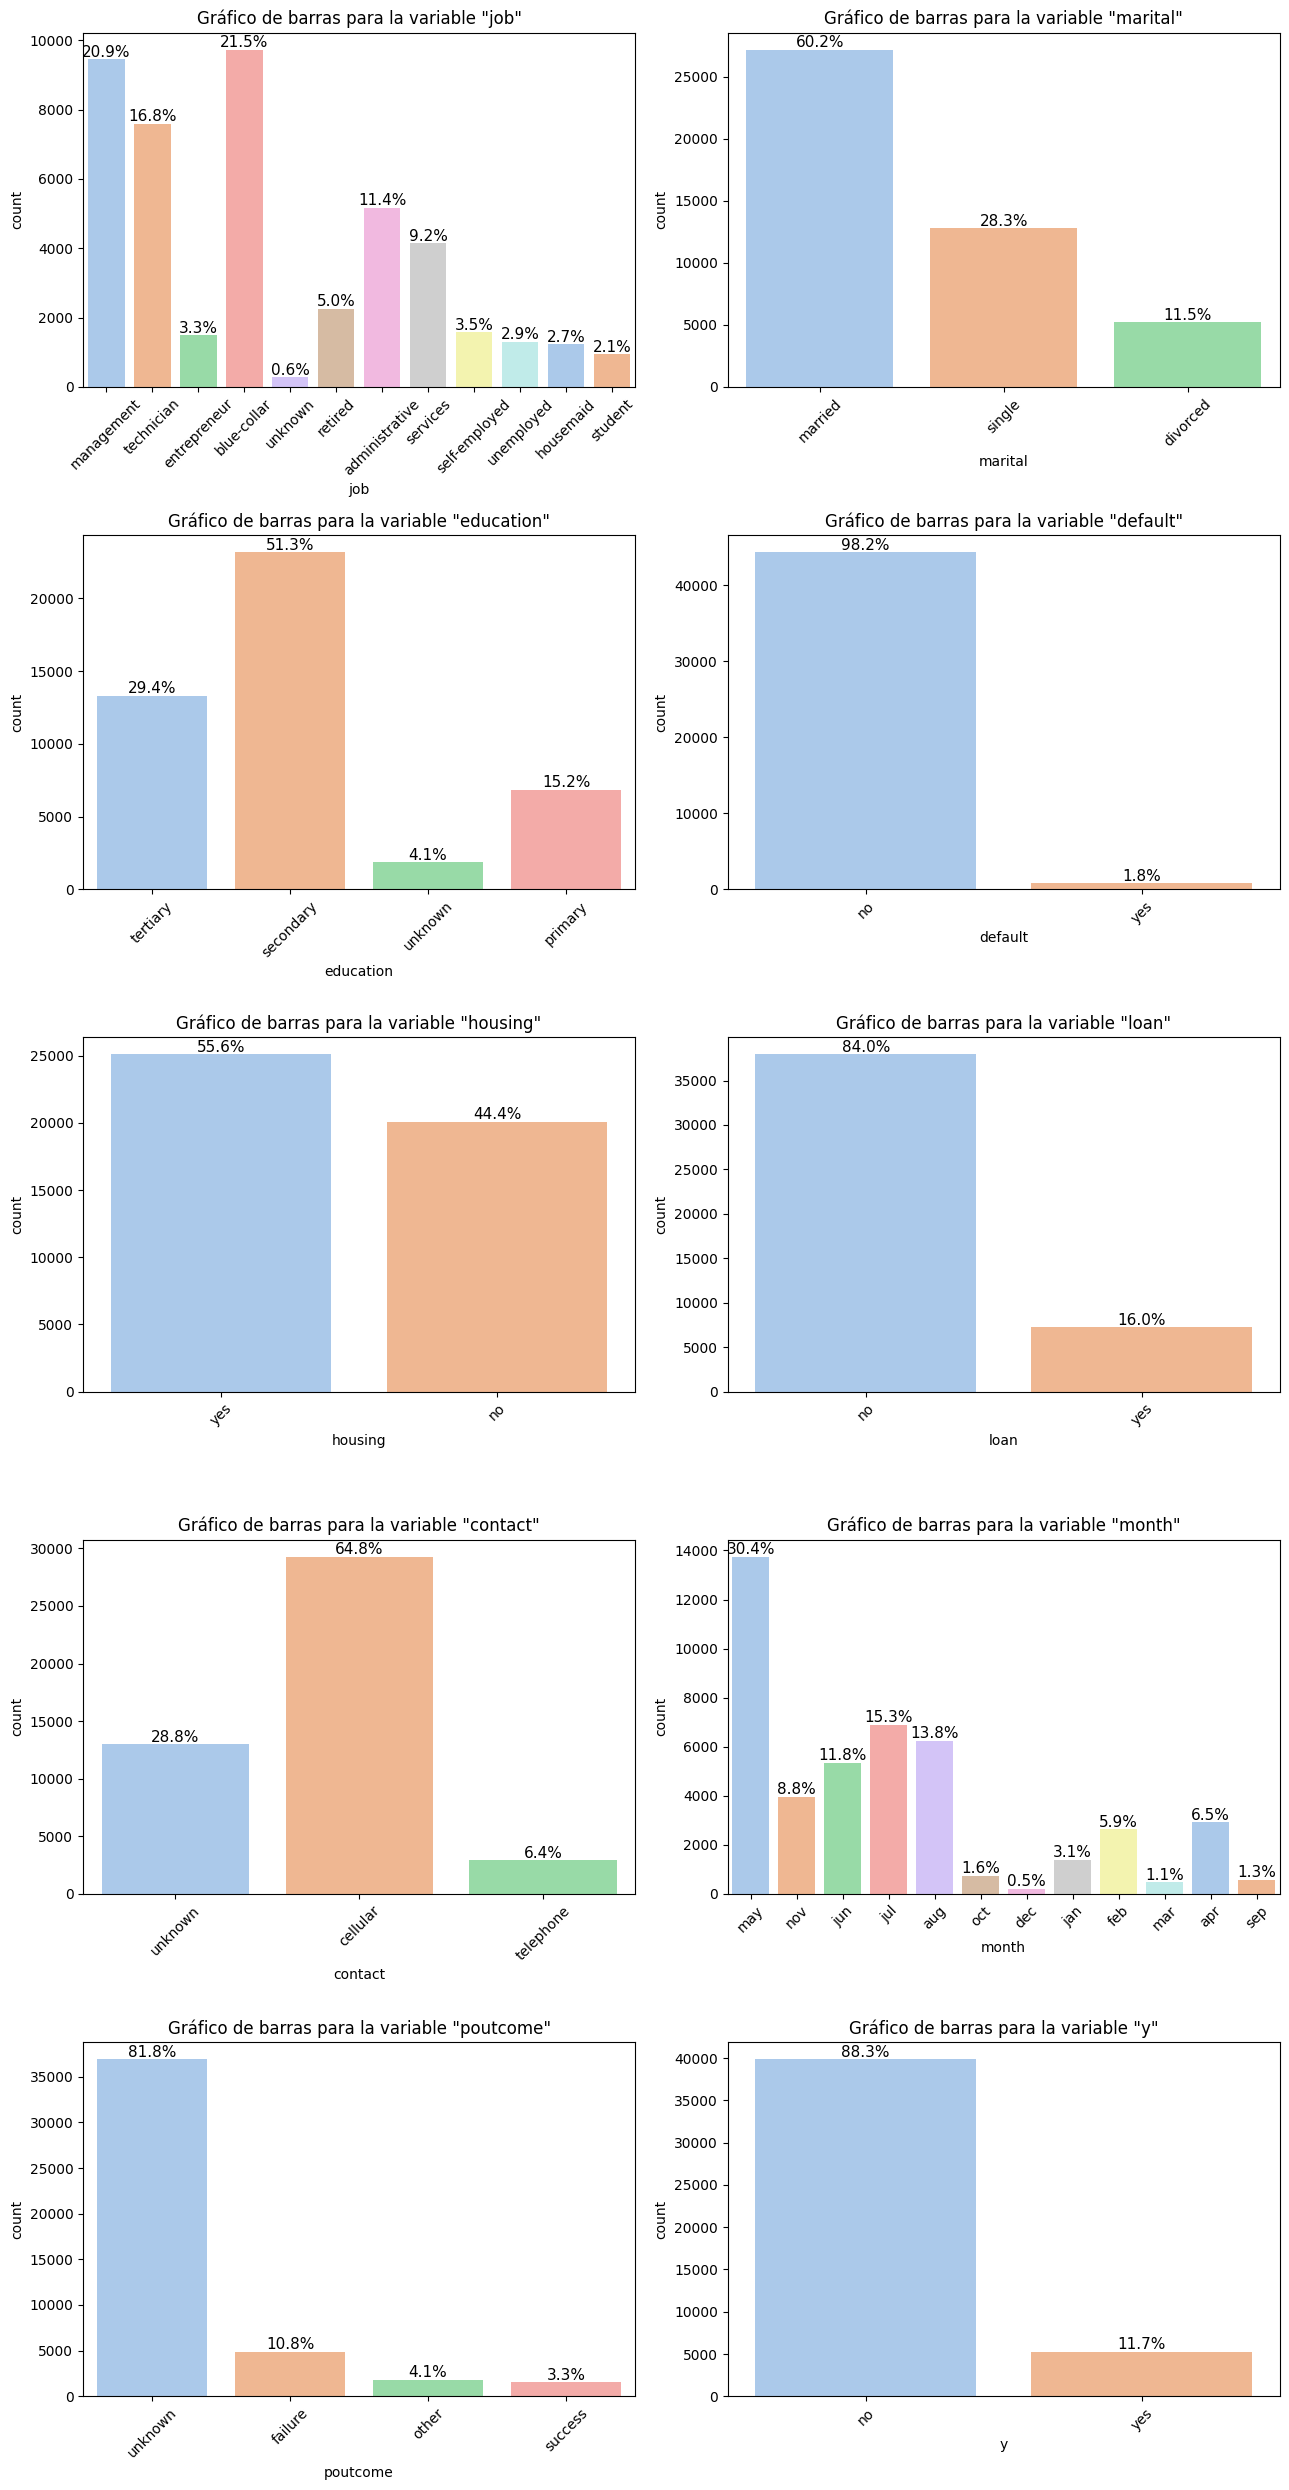

In [7]:
# Gráficos de barras para variables categóricas
categorical_vars = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome", "y"]
num_plots = len(categorical_vars)
num_rows = num_plots // 2 + num_plots % 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(13, 25))

for i, var in enumerate(categorical_vars):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]
    sns.countplot(data=data, x=var, ax=ax, palette="pastel")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    # Calcular el porcentaje de cada categoría
    total = len(data[var])
    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', fontsize=11, 
                    color='black', xytext=(0, 5), 
                    textcoords='offset points')
    
    ax.set_title(f'Gráfico de barras para la variable "{var}"')

# Eliminar subplots vacíos
for i in range(num_plots, num_rows*num_cols):
    axes.flatten()[i].remove()

plt.tight_layout()
plt.show()


### Resumen

Centrándonos en la distribución de las muestras del conjunto de datos, vemos que todas las variables numéricas, a excepción de la variable 'day', están muy sesgadas hacia la izquierda, con una larga cola hacia los extremos más altos, y en la mayoría de las variables categóricas las clases no están balanceadas. 

La variable que representará un mayor problema en el futuro es la "y" ya que es la variable objetivo y el número de muestras con respuesta "yes" representa solo el 11.7% del total.
Por otra parte, la variable "poutcome", que representa el resultado de la campaña de marketing anterior, podría ser una variable importante para resolver nuestro problema. Sin embargo, el 81.8% de las muestras presentan un resultado desconocido mientras que las que presentan un resultado exitoso (el resultado de mayor interés) solo representan un 3.3% del total de la muestra.

## 2. Análisis Univariado

### Variables Categóricas

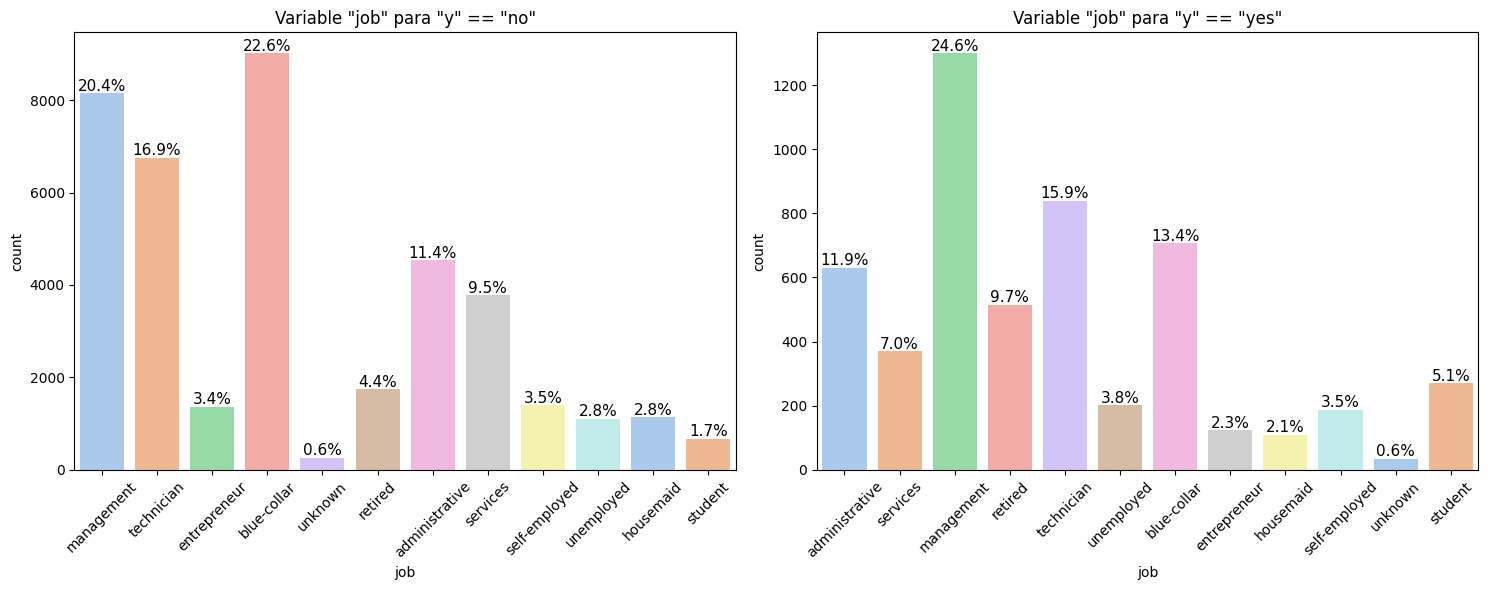

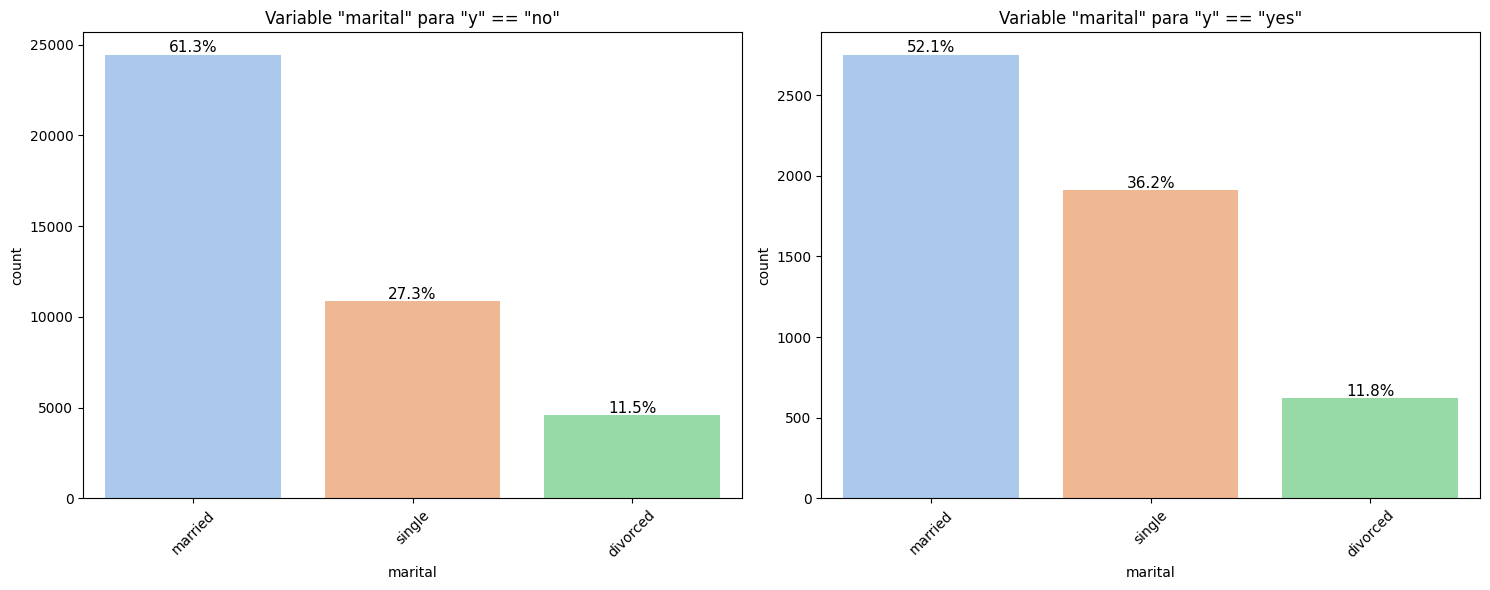

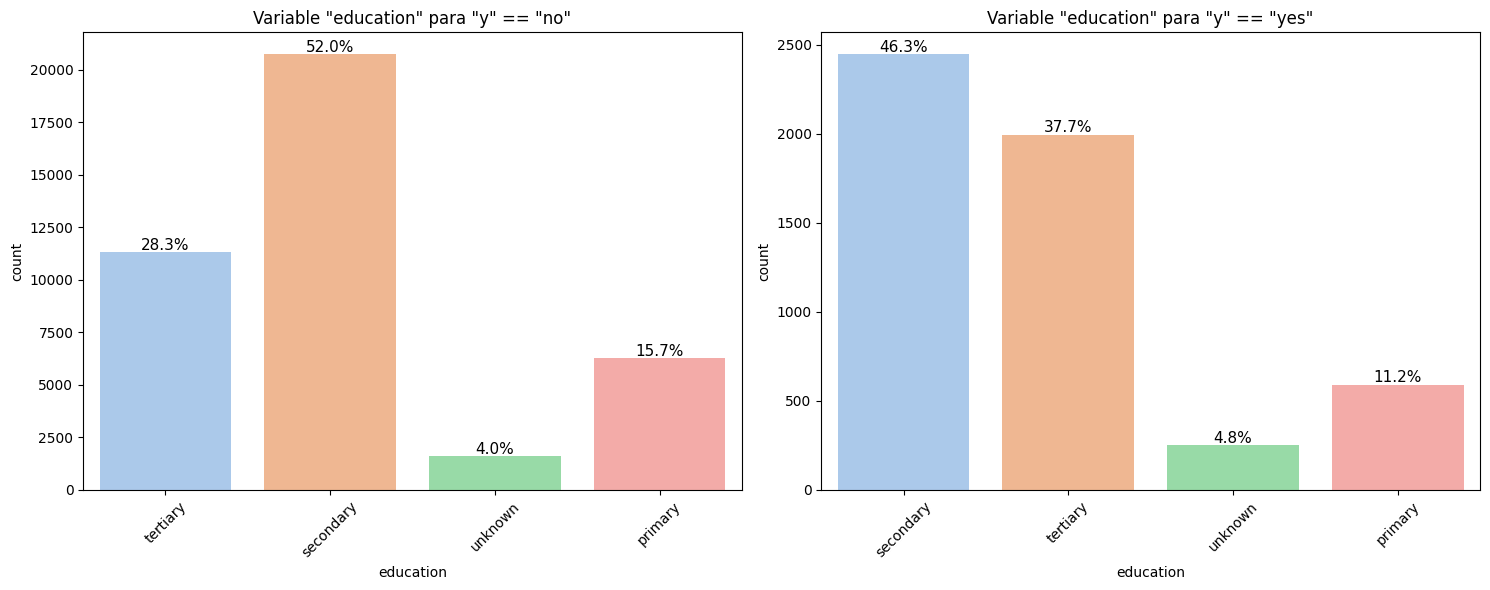

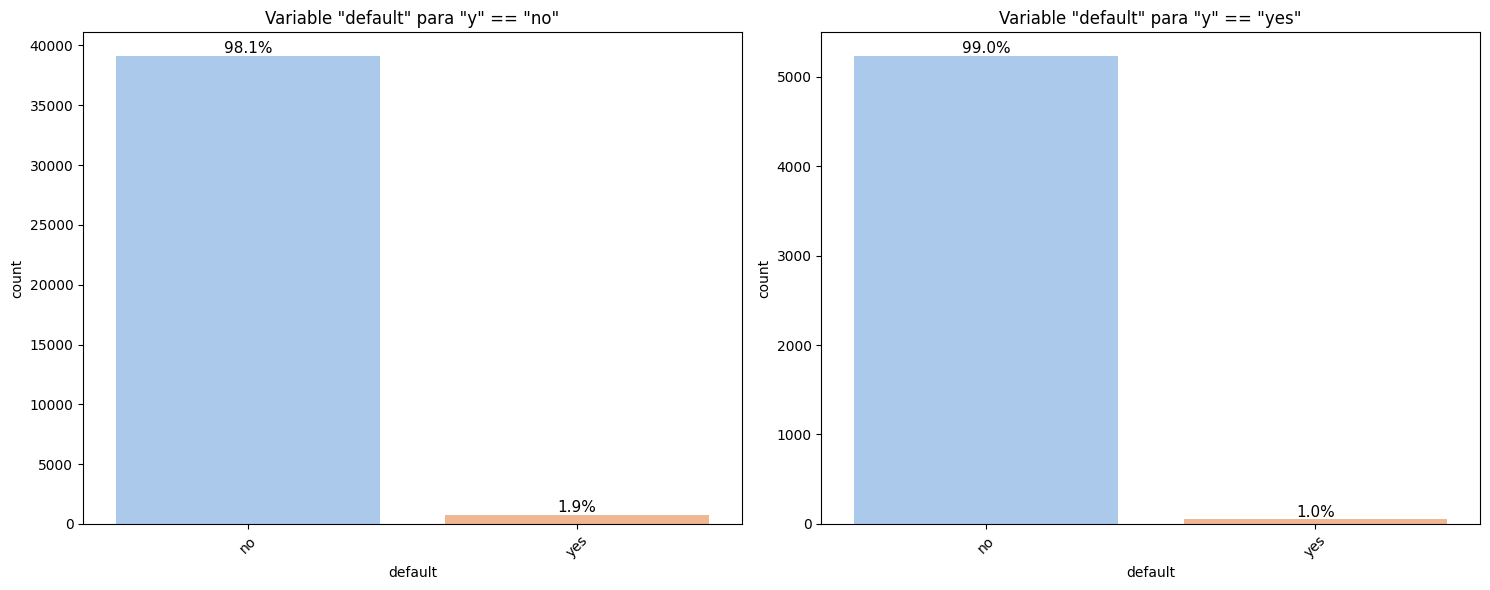

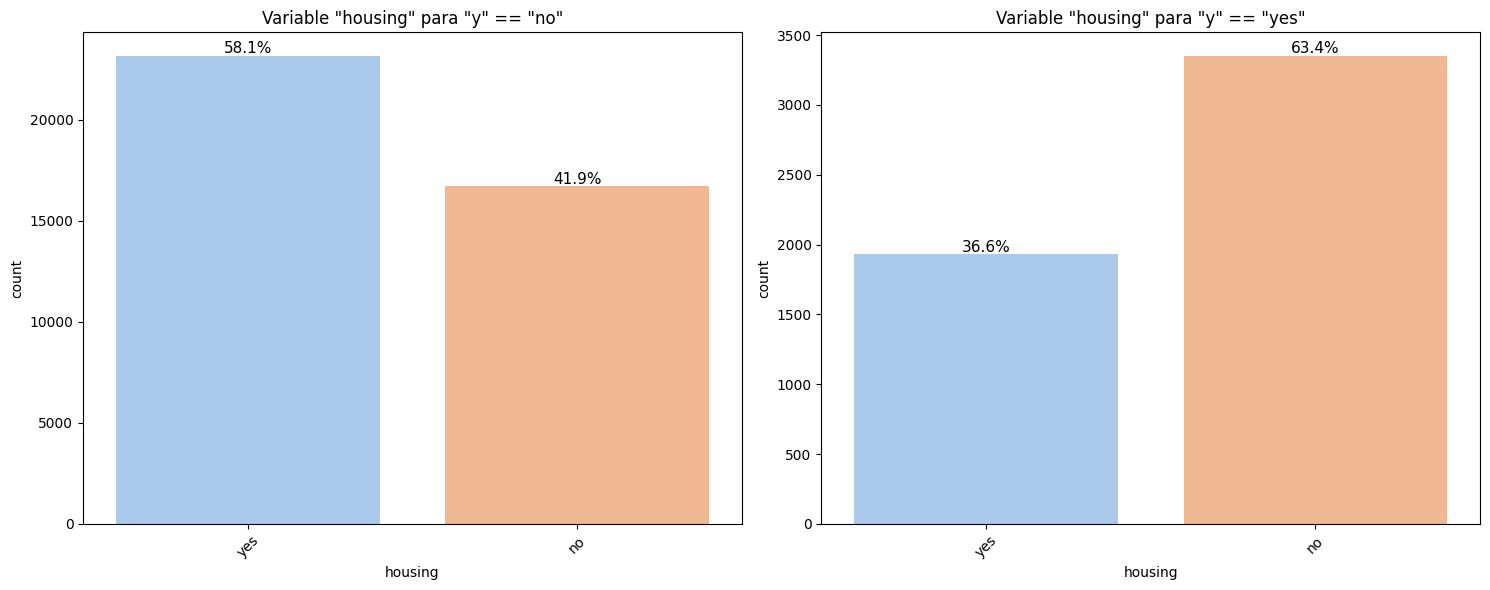

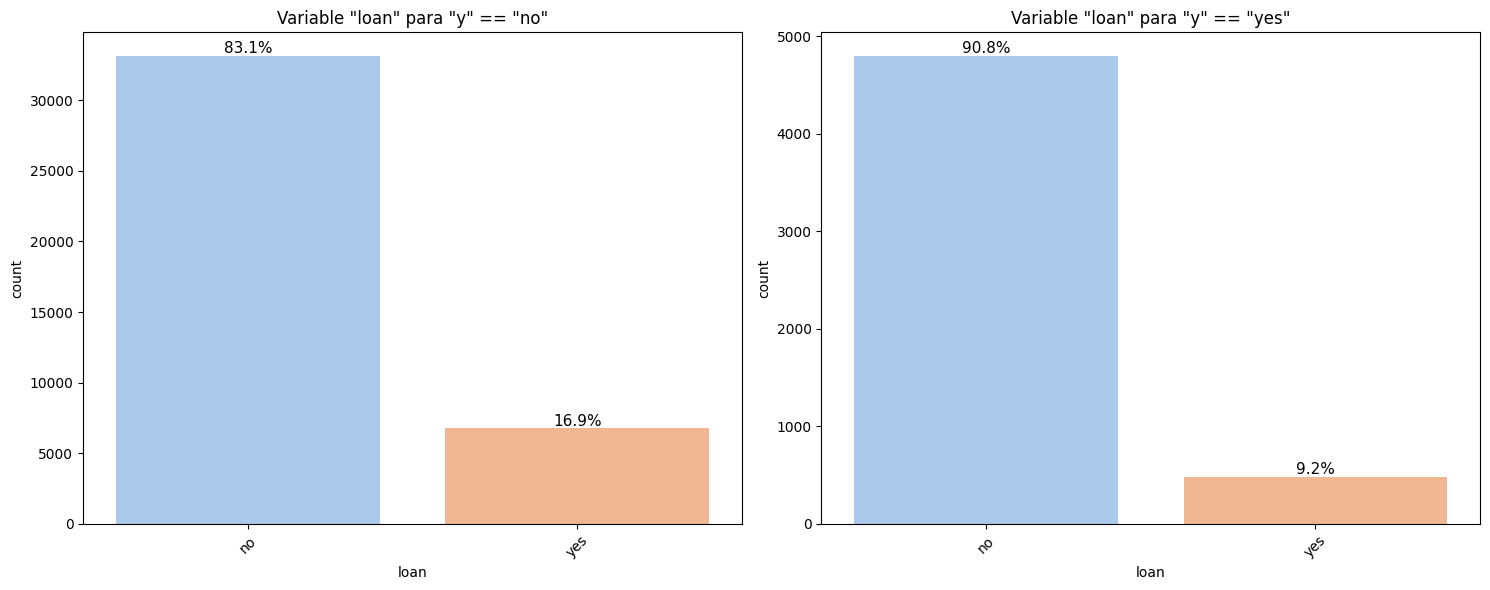

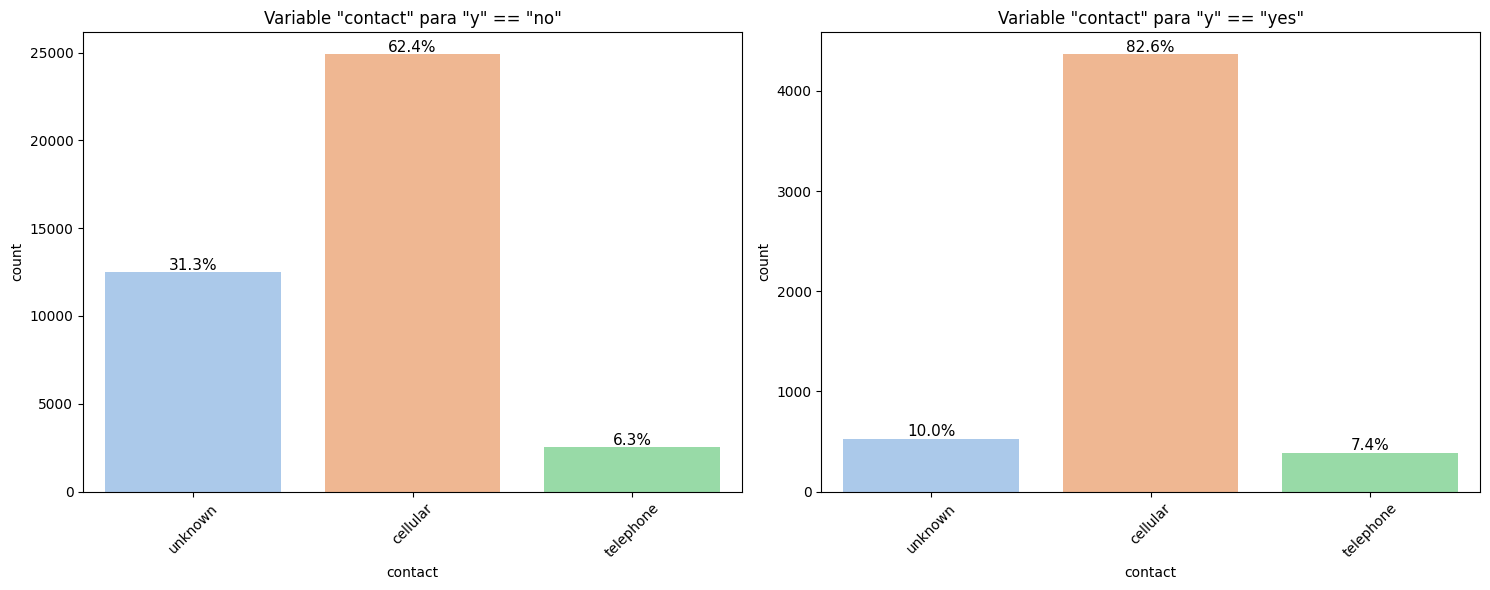

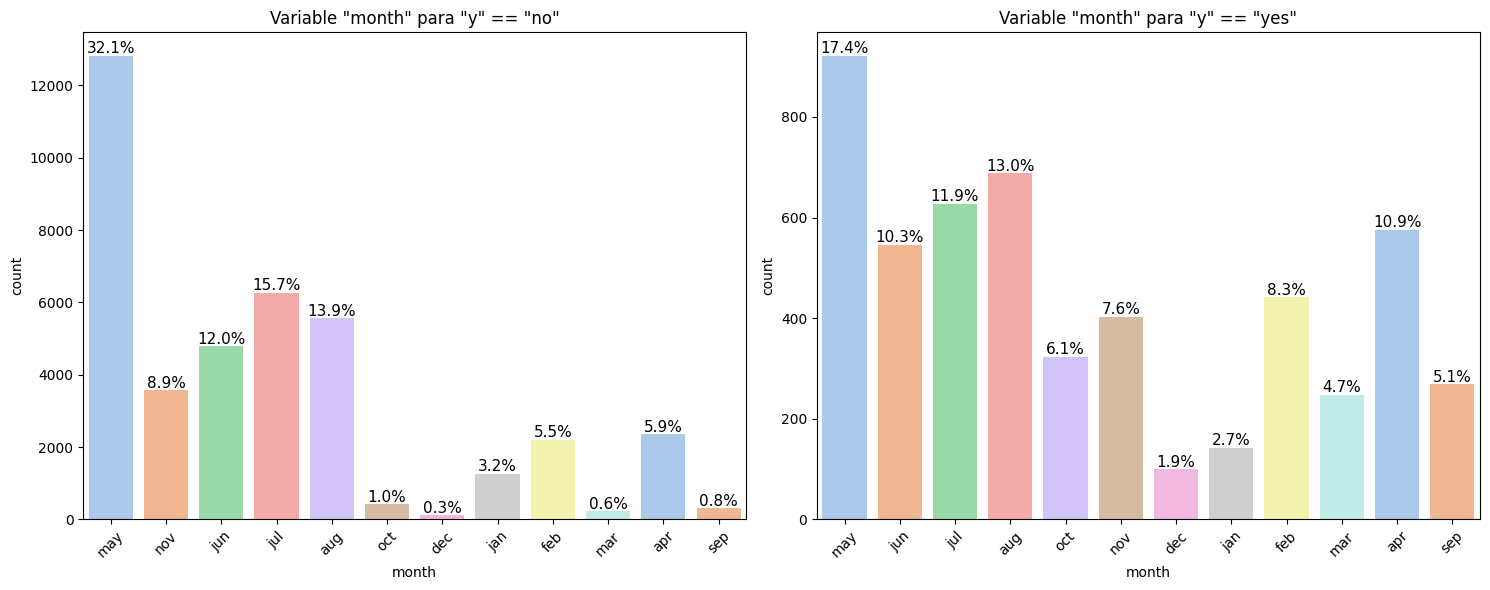

In [8]:
# Filtrar el DataFrame para tener dos subconjuntos de datos
data_no = data[data["y"] == "no"]
data_yes = data[data["y"] == "yes"]

# Variables categóricas de interés
categorical_vars = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

# Gráficos de barras apiladas para variables categóricas vs. y con porcentajes
for var in categorical_vars[:-1]:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico para "y" == "no"
    ax = sns.countplot(data=data_no, x=var, ax=axes[0], palette="pastel")
    axes[0].set_title(f'Variable "{var}" para "y" == "no"')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
    
    total_no = float(len(data_no[var]))
    for p in ax.patches:
        height = p.get_height()
        axes[0].annotate(f'{height / total_no:.1%}', (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    
    # Gráfico para "y" == "yes"
    ax = sns.countplot(data=data_yes, x=var, ax=axes[1], palette="pastel")
    axes[1].set_title(f'Variable "{var}" para "y" == "yes"')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    total_yes = float(len(data_yes[var]))
    for p in ax.patches:
        height = p.get_height()
        axes[1].annotate(f'{height / total_yes:.1%}', (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()


#### Resumen

Analizando cada variable individualmente, según si la persona está interesada en el depósito o no, podemos hacer las siguientes observaciones:

- En lo que respecta al trabajo, vemos que del grupo que sí está interesado, las personas que trabajan en dirección representan un 24.6%, las que tienen un trabajo de clase obrera respresentan un 13.4% y las que trabajan en servicios respresentan un 7% mientras que en el grupo de los que no están interesados, estas profesiones representan un 20.4%, 22.6% y 9.5%, respectivamente.
  
- En cuanto al estado marital, el 36.2% de las personas que están interesadas están solteras, mientras que este grupo disminuye a un 27.3% en el grupo de las que no.
  
- En la variable 'housing' podemos ver que la mayoria de las personas que están interesadas en el depósito(63.4%) no tienen un crédito hipotecario.
  
- Al 82.6% de las personas que están interesadas se les contacta por teléfono móvil.

### Variables Numéricas

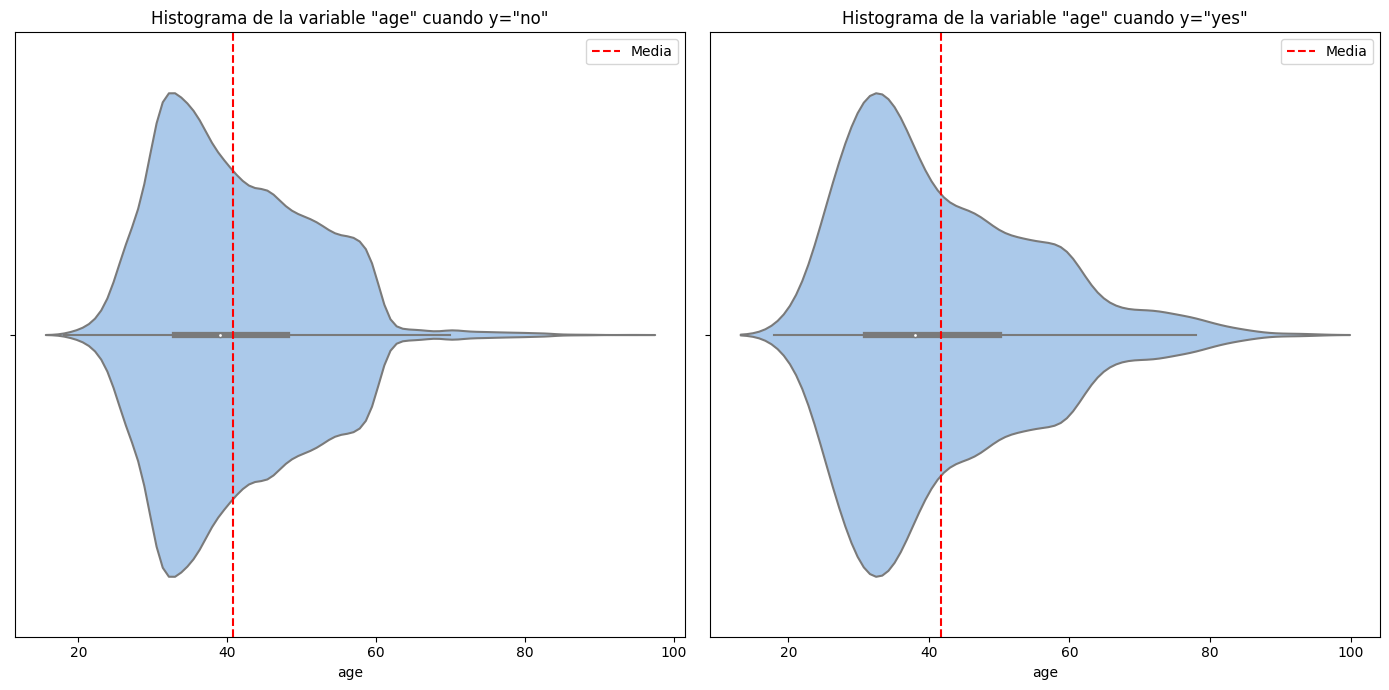

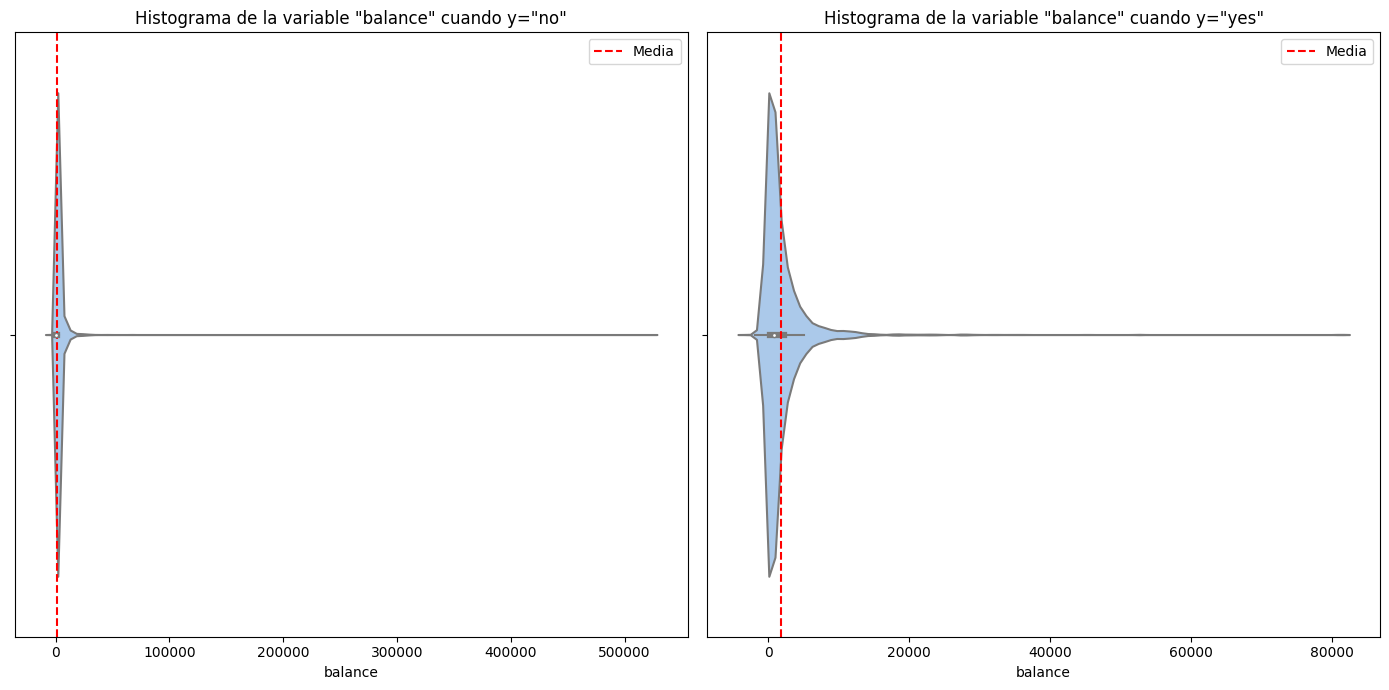

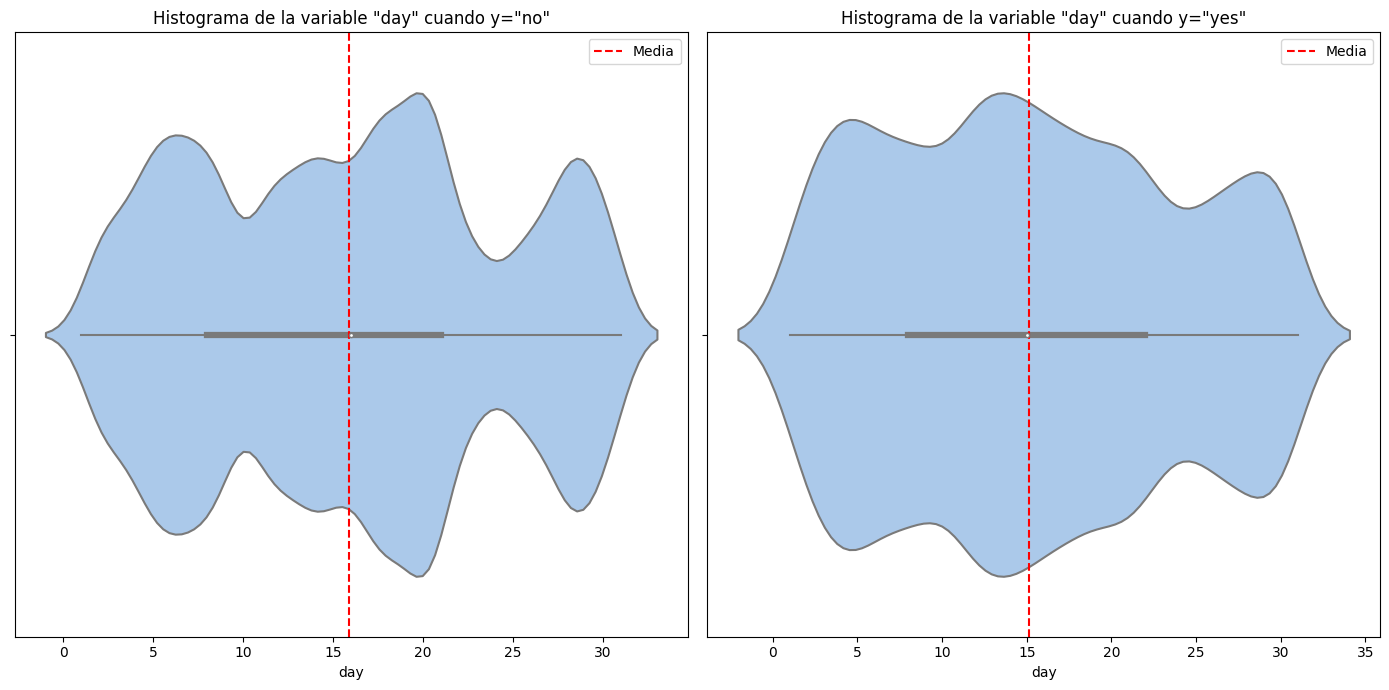

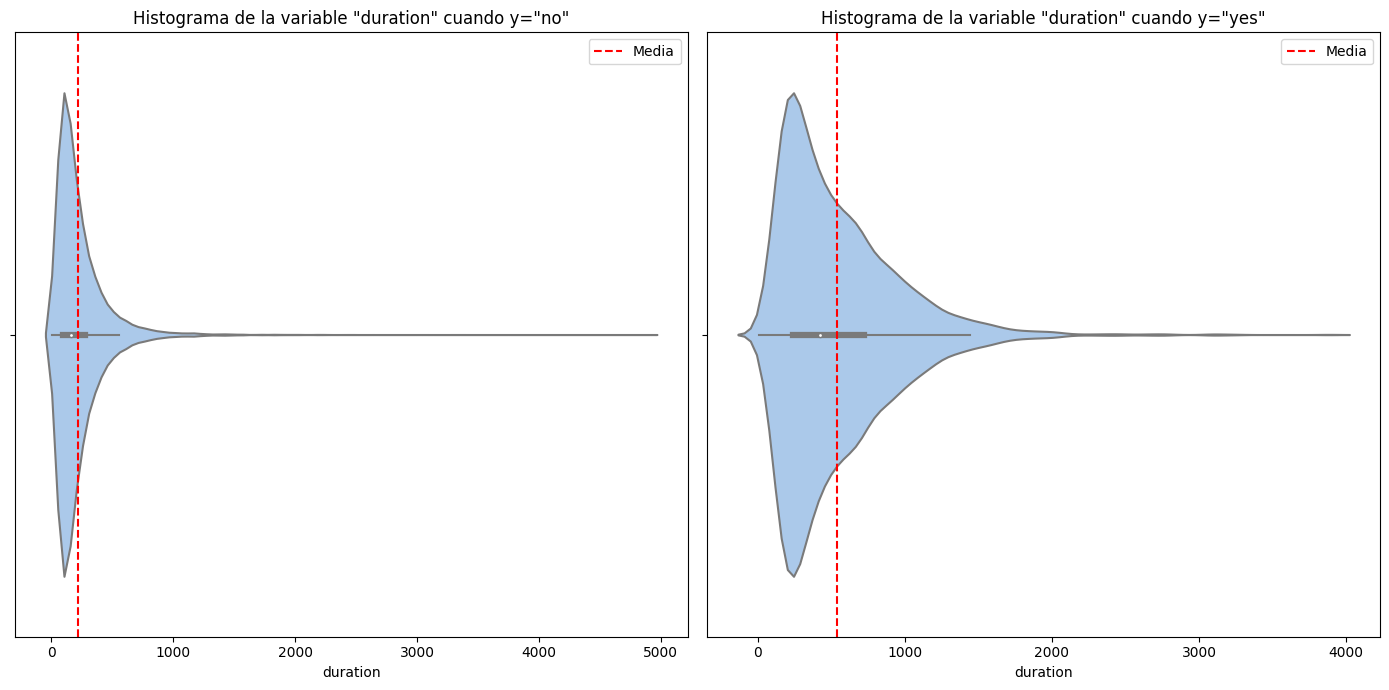

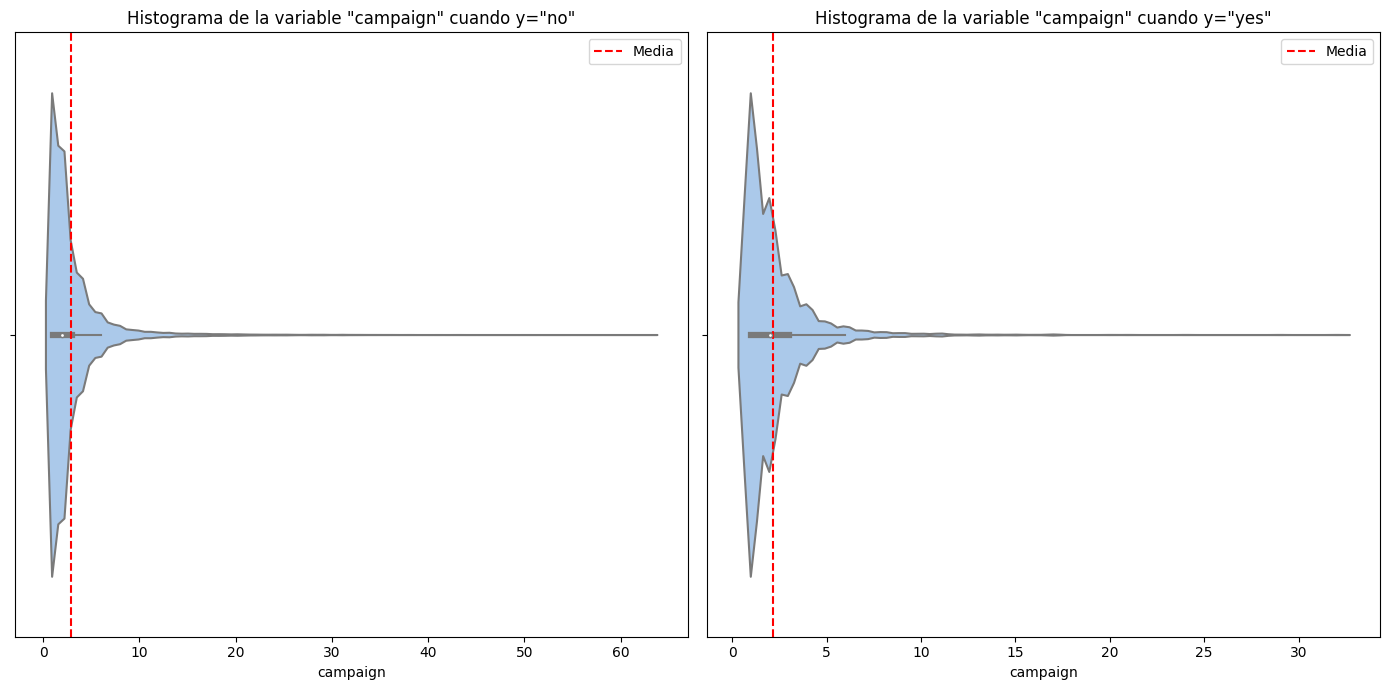

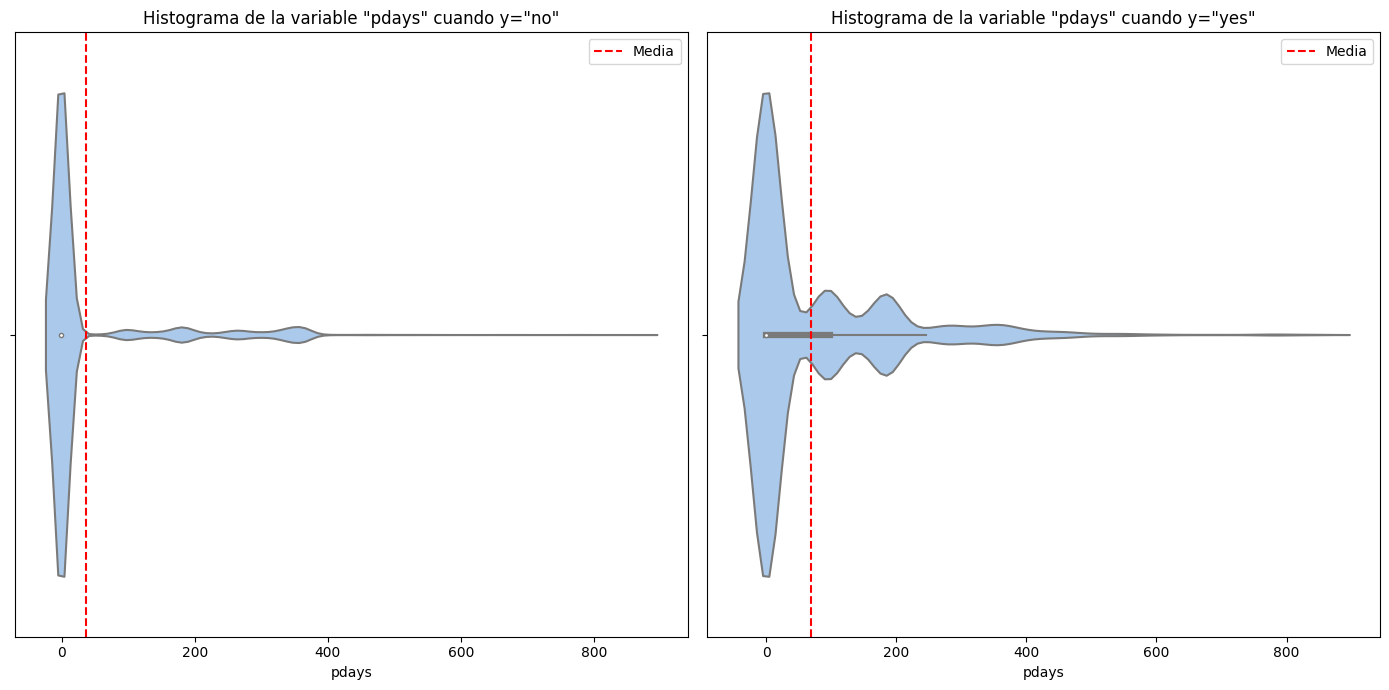

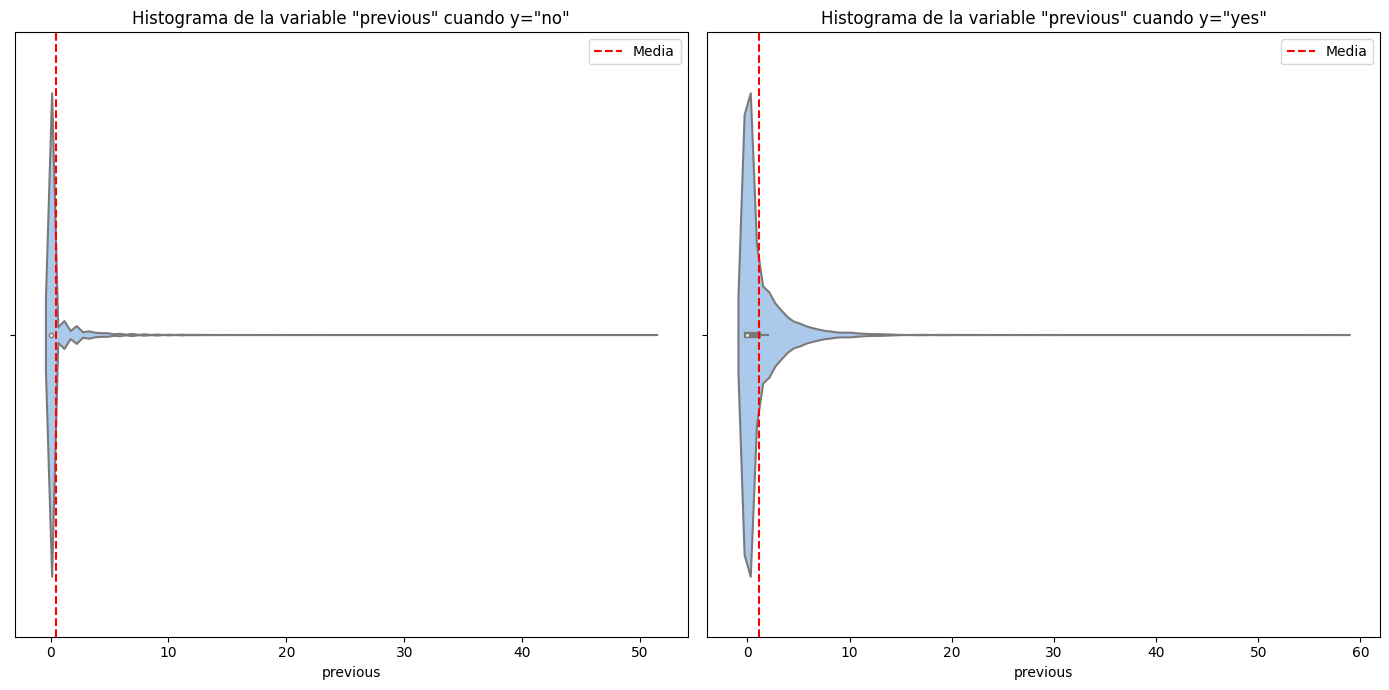

In [9]:
for var in numeric_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for i, outcome in enumerate(["no", "yes"]):
        ax = sns.violinplot(data=data[data['y'] == outcome], x=var, kde=True, ax=axes[i], palette = 'pastel')
        ax.set_title(f'Histograma de la variable "{var}" cuando y="{outcome}"')
        ax.axvline(data[data['y'] == outcome][var].mean(), color='red', linestyle='--', label='Media')
        ax.legend()
    plt.tight_layout()
    plt.show()

#### Resumen

En cuanto a las variables numéricas podemos hacer las siguientes observaciones:

- La distribución de la edad se encentra en los mismos rangos para ambos grupos, pero la frecuencia de los años 40 a los 90 es mayor en las personas que sí están interesadas en el depósito.
  
- Las personas que no están interesadas en el depósito tienen un balance muy bajo, cercano a 0.
  
- La duración del contacto suele ser más alta con las personas que sí están interesadas. Por la variable 'pdays' se ve que estás personas son contactadas con más antelación que las que no lo están, y el número de veces que se contacta con ellas también es superior.

- En las variables 'balance', 'duration', 'campaign', 'pdays' y 'previous' seguimos teniendo algunos outliers, ya que las distribuciones se extienden mucho hacia el extremo superior prácticamaente con frecuencia 0.

## 3. Análisis Bivariado

In [21]:
from sklearn.preprocessing import LabelEncoder

# Lista de variables categóricas a codificar
categorical_vars = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

# Inicializa el codificador de etiquetas
label_encoders = {}

# Itera sobre cada variable categórica y aplica la codificación de etiquetas
for column_name in categorical_vars:
    # Inicializa el codificador de etiquetas para la columna actual
    label_encoder = LabelEncoder()
    # Ajusta y transforma la columna categórica
    data[column_name + "_encoded"] = label_encoder.fit_transform(data[column_name])
    # Almacena el codificador de etiquetas para su uso posterior
    label_encoders[column_name] = label_encoder

# Muestra las primeras filas del DataFrame con las columnas codificadas
print("Primeras filas del DataFrame con las columnas codificadas:")
print(data[[column_name + "_encoded" for column_name in categorical_vars]].head())



Primeras filas del DataFrame con las columnas codificadas:
   job_encoded  marital_encoded  education_encoded  default_encoded  \
0            4                1                  2                0   
1            9                2                  1                0   
2            2                1                  1                0   
3            1                1                  3                0   
4           11                2                  3                0   

   housing_encoded  loan_encoded  contact_encoded  month_encoded  \
0                1             0                2              8   
1                1             0                2              8   
2                1             1                2              8   
3                1             0                2              8   
4                0             0                2              8   

   poutcome_encoded  
0                 3  
1                 3  
2                 3  
3                

In [26]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,y,job_encoded,marital_encoded,education_encoded,default_encoded,housing_encoded,loan_encoded,contact_encoded,month_encoded,poutcome_encoded
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,...,no,4,1,2,0,1,0,2,8,3
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,...,no,9,2,1,0,1,0,2,8,3
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,...,no,2,1,1,0,1,1,2,8,3
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,...,no,1,1,3,0,1,0,2,8,3
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,...,no,11,2,3,0,0,0,2,8,3


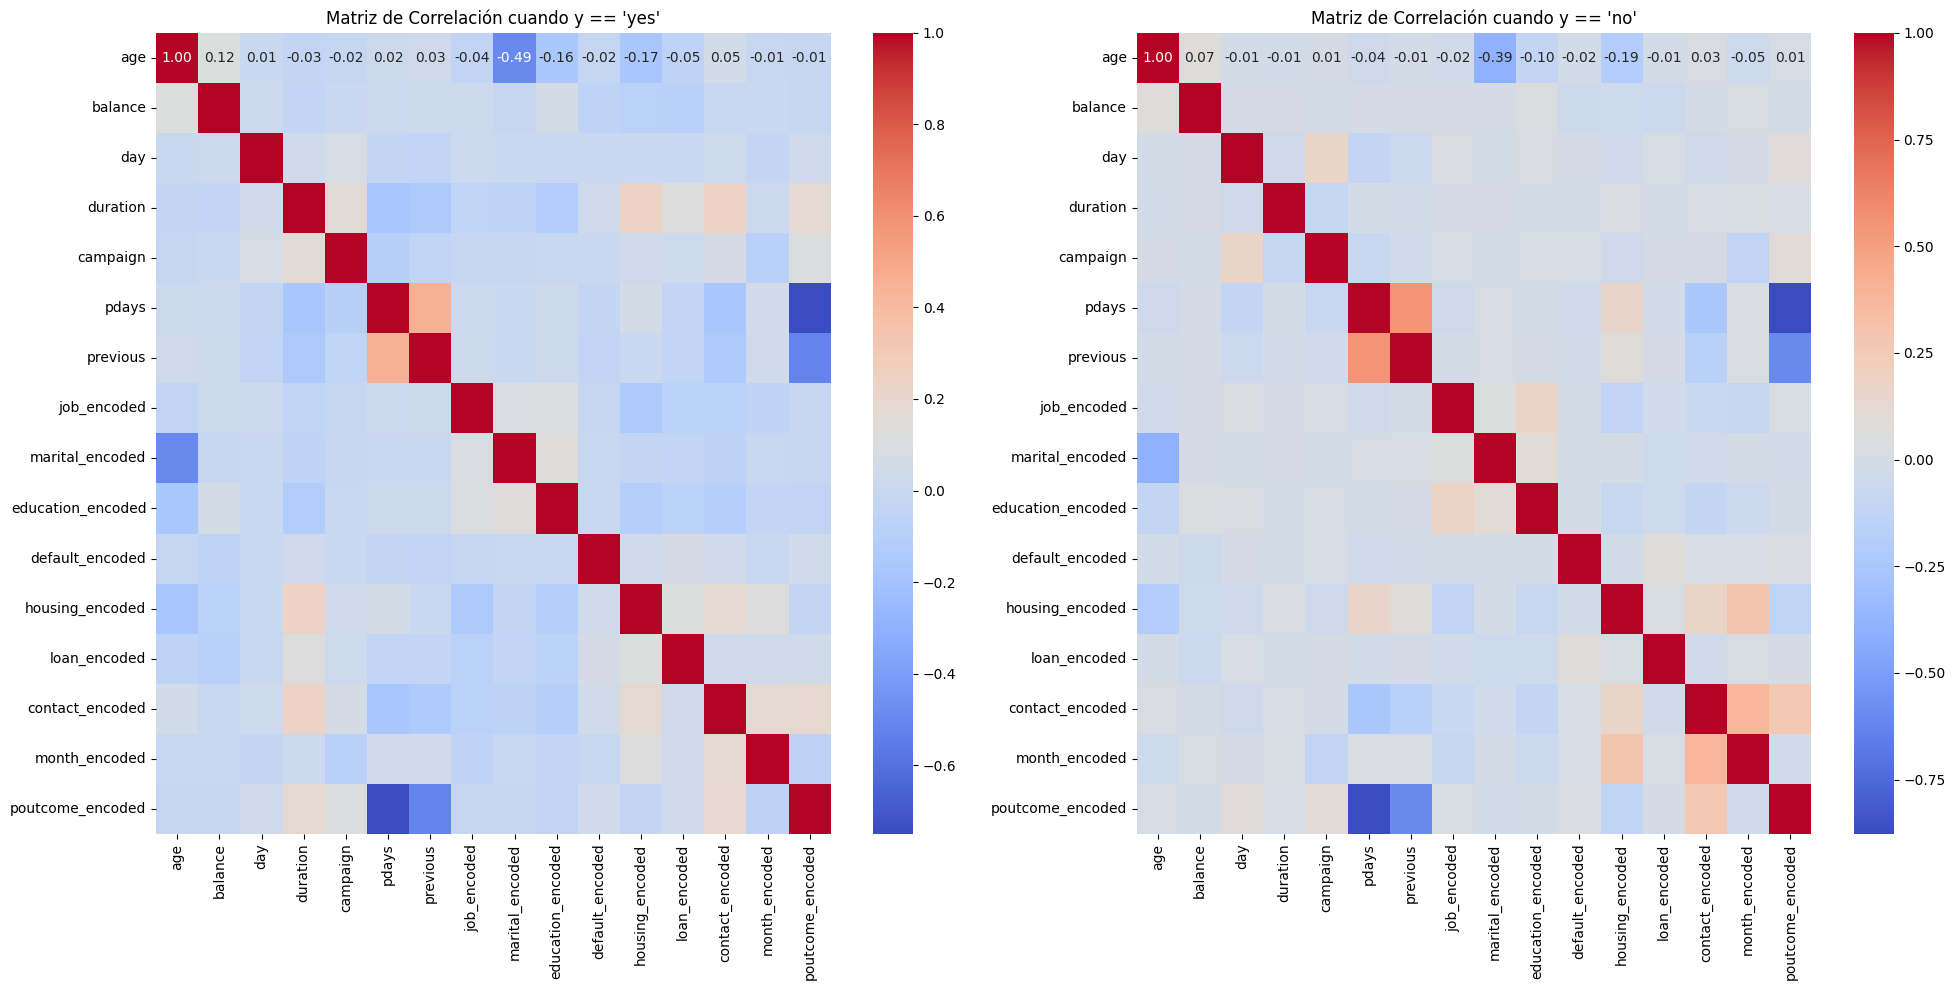

In [25]:
# Concatena las variables numéricas y las variables codificadas en un solo DataFrame
numerical_vars = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
all_vars = numerical_vars + [column_name + "_encoded" for column_name in categorical_vars]

# Filtrar los datos cuando y == 'yes'
data_yes = data[data['y'] == 'yes']

# Filtrar los datos cuando y == 'no'
data_no = data[data['y'] == 'no']

# Calcula la matriz de correlación para y == 'yes'
correlation_matrix_yes = data_yes[all_vars].corr()

# Calcula la matriz de correlación para y == 'no'
correlation_matrix_no = data_no[all_vars].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Graficar la matriz de correlación para y == 'yes'
sns.heatmap(correlation_matrix_yes, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Matriz de Correlación cuando y == \'yes\'')

# Graficar la matriz de correlación para y == 'no'
sns.heatmap(correlation_matrix_no, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Matriz de Correlación cuando y == \'no\'')

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()



### Resumen

En cuanto a las correlaciones podemos ver que no hay grandes diferencias entre las características de las personas que están interesadas en el depósito y las que no.

Lo único que cambia ligeramente es que la correlación negativa de algunas variables cuando la persona está interesada se vuelve más débil cuando la persona no está interesada y cuando hay una correlacion positiva, se vuelve más fuerte cuando la persona no está interesada en el depósito.

Por ejemplo, cuando la persona sí está interesada, hay una leve correlación entre el método de contacto y la duración del mismo y esta correlación se vuelve inexistente cuando la persona no está interesada en el depósito.

# Conclusiones

Una vez finalizado el análisis exploratorio de nuestros datos podemos resumir los hayazgos encontrados con las siguientes conclusiones:

- Muchas de las variables numéricas presentan una distribución sesgada hacia la izquierda, con una larga cola hacia los extremos más alto.
  
- La variable que representará un mayor problema en el futuro es la "y" ya que es la variable objetivo y el número de muestras con respuesta "yes" representa solo el 11.7% del total.

- La variable "poutcome", que representa el resultado de la campaña de marketing anterior, podría ser una variable importante para resolver nuestro problema. Sin embargo, el 81.8% de las muestras presentan un resultado desconocido mientras que las que presentan un resultado exitoso (el resultado de mayor interés) solo representan un 3.3% del total de la muestra.
 
- La mayoría de las personas que están interesadas en el depósito(63.4%) no tienen un crédito hipotecario.
  
- Al 82.6% de las personas que están interesadas se les contacta por teléfono móvil.

- Las personas que no están interesadas en el depósito tienen un balance muy bajo, cercano a 0.
  
- La duración del contacto suele ser más alta con las personas que sí están interesadas. Por la variable 'pdays' se ve que estás personas son contactadas con más antelación que las que no lo están, y el número de veces que se contacta con ellas también es superior.

- Algunas variables como 'balance' o 'pdays' siguen teniendo valores atípicos.